In [1]:
import nibabel as nib
import matplotlib.pyplot as plt
import os
import numpy as np

In [2]:
# mount colab and my personal drive (locaiton of OASIS data,
# both compressed and raw files written to it below)
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# variable for data connection!! use at top of files
DRIVE_ROOT  = "/content/drive/MyDrive/OASIS"
MRI_DIR = os.path.join(DRIVE_ROOT, "raw")       # extracted files in Drive

In [4]:
# check path for part 1 or 2, and existence of raw folder
print(MRI_DIR)
print(os.path.exists(MRI_DIR))

/content/drive/MyDrive/OASIS/raw
True


## test MRI image display

# NON DEMENTED

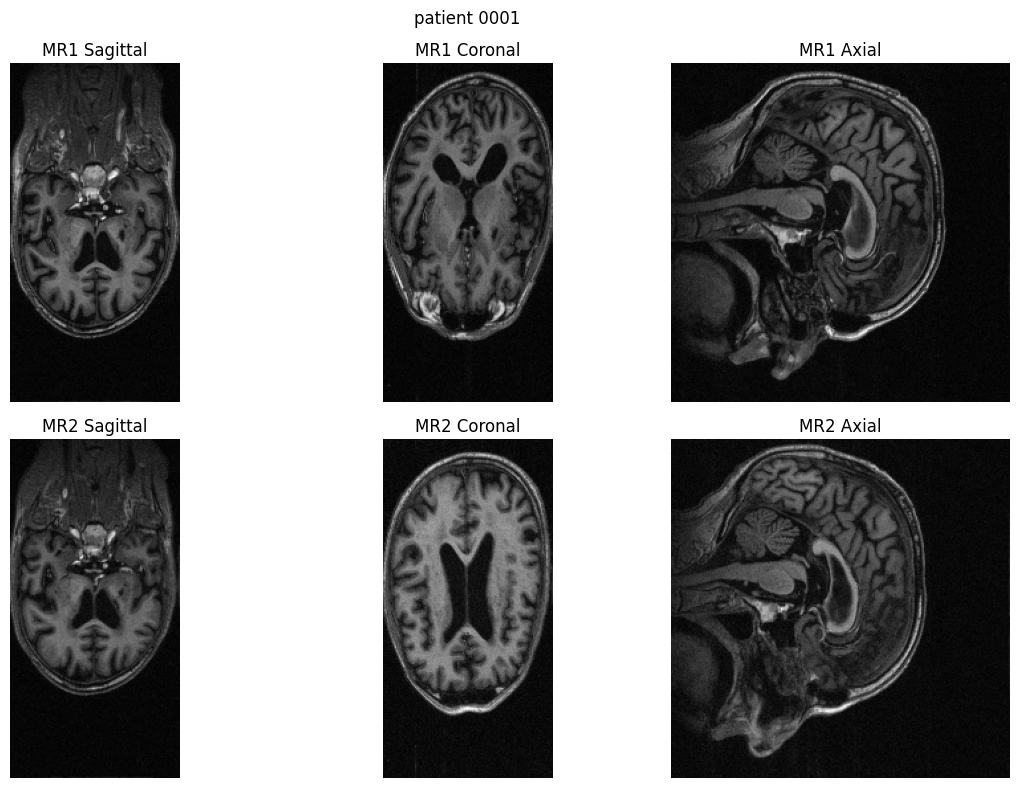

Volume shape: (256, 256, 128, 1)
MR1 runs averaged: 3
MR2 runs averaged: 3


In [5]:
# identify how many imaging runs they did for this patient at each
# scan (MR[#]) and average across the scans to reduce noise
def load_averaged_img(subject_dir):
    runs = []
    for root, dirs, files in os.walk(subject_dir):
        for f in sorted(files):
            if f.endswith(".img"):
                runs.append(nib.load(os.path.join(root, f)).get_fdata())
    if not runs:
        return None
    return np.mean(runs, axis=0)

# display only 2 days of scans (MR1 and MR2)
data1 = load_averaged_img(os.path.join(MRI_DIR, "OAS2_0001_MR1"))
data2 = load_averaged_img(os.path.join(MRI_DIR, "OAS2_0001_MR2"))

# plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, (data, label) in enumerate([(data1, "MR1"), (data2, "MR2")]):
    mid = [data.shape[j] // 2 for j in range(3)]
    axes[i, 0].imshow(data[mid[0], :, :], cmap="gray")
    axes[i, 0].set_title(f"{label} Sagittal")
    axes[i, 1].imshow(data[:, mid[1], :], cmap="gray")
    axes[i, 1].set_title(f"{label} Coronal")
    axes[i, 2].imshow(data[:, :, mid[2]], cmap="gray")
    axes[i, 2].set_title(f"{label} Axial")
for ax in axes.flat:
    ax.axis("off")
plt.suptitle("patient 0001")
plt.tight_layout()
plt.show()

# descriptions
print(f"Volume shape: {data1.shape}")
print(f"MR1 runs averaged: {len([f for r, d, files in os.walk(os.path.join(MRI_DIR, 'OAS2_0001_MR1')) for f in files if f.endswith('.img')])}")
print(f"MR2 runs averaged: {len([f for r, d, files in os.walk(os.path.join(MRI_DIR, 'OAS2_0001_MR2')) for f in files if f.endswith('.img')])}")

# DEMENTED

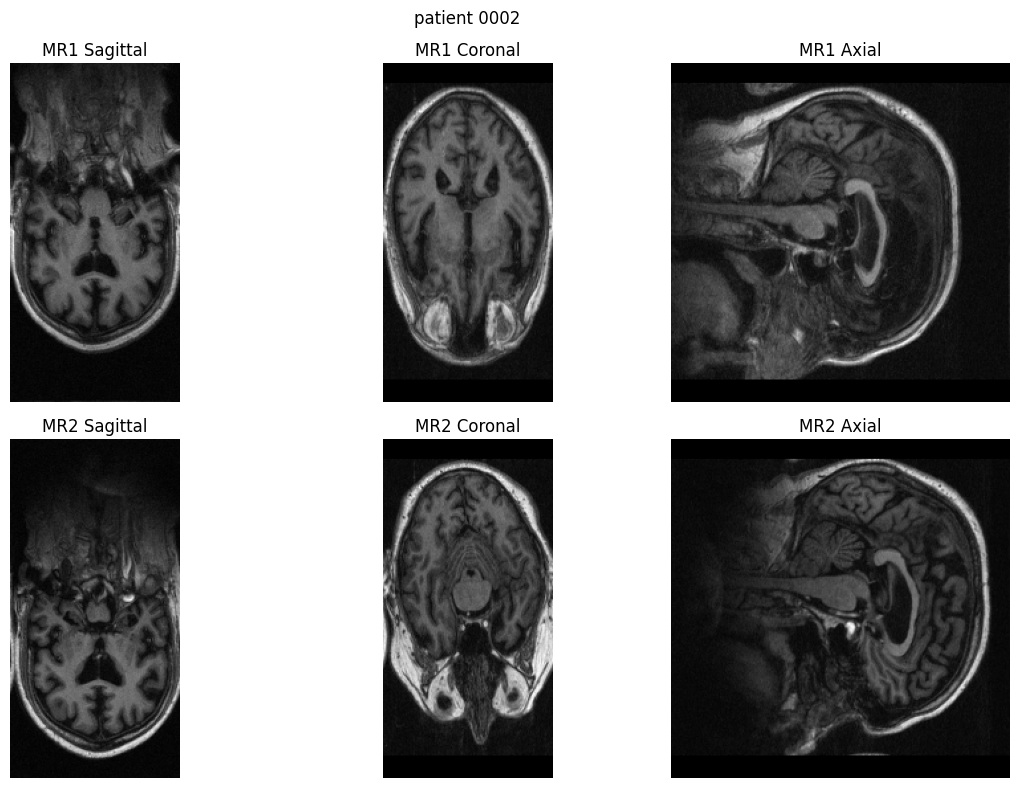

Volume shape: (256, 256, 128, 1)
MR1 runs averaged: 4
MR2 runs averaged: 4


In [6]:
# identify how many imaging runs they did for this patient at each
# scan (MR[#]) and average across the scans to reduce noise
def load_averaged_img(subject_dir):
    runs = []
    for root, dirs, files in os.walk(subject_dir):
        for f in sorted(files):
            if f.endswith(".img"):
                runs.append(nib.load(os.path.join(root, f)).get_fdata())
    if not runs:
        return None
    return np.mean(runs, axis=0)

# display only 2 days of scans (MR1 and MR2)
data1 = load_averaged_img(os.path.join(MRI_DIR, "OAS2_0002_MR1"))
data2 = load_averaged_img(os.path.join(MRI_DIR, "OAS2_0002_MR2"))

# plotting
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, (data, label) in enumerate([(data1, "MR1"), (data2, "MR2")]):
    mid = [data.shape[j] // 2 for j in range(3)]
    axes[i, 0].imshow(data[mid[0], :, :], cmap="gray")
    axes[i, 0].set_title(f"{label} Sagittal")
    axes[i, 1].imshow(data[:, mid[1], :], cmap="gray")
    axes[i, 1].set_title(f"{label} Coronal")
    axes[i, 2].imshow(data[:, :, mid[2]], cmap="gray")
    axes[i, 2].set_title(f"{label} Axial")
for ax in axes.flat:
    ax.axis("off")
plt.suptitle("patient 0002")
plt.tight_layout()
plt.show()

# descriptions
print(f"Volume shape: {data1.shape}")
print(f"MR1 runs averaged: {len([f for r, d, files in os.walk(os.path.join(MRI_DIR, 'OAS2_0002_MR1')) for f in files if f.endswith('.img')])}")
print(f"MR2 runs averaged: {len([f for r, d, files in os.walk(os.path.join(MRI_DIR, 'OAS2_0002_MR2')) for f in files if f.endswith('.img')])}")